## 1. Scratchpad Final

In [1]:
import pickle, copy, gc
from tqdm.notebook import tqdm
from collections import Counter
import BPE_tokenizer, Data, Model, Trainer, Predict
from BPE_tokenizer import BPETokenizer, BPEEncoder, tokenize_eng, tokenize_pol
import pandas as pd
#from tqdm.auto import tqdm


In [3]:
# with open("../data/tokenizer_euro_pol.pkl", 'rb') as f:
#     tokenizer_pol = pickle.load(f)

# with open("../data/tokenizer_euro_eng.pkl", 'rb') as f:
#     tokenizer_eng = pickle.load(f)

with open("../data/dataframe_europarl.pkl", 'rb') as f:
    df_europarl = pickle.load(f)

with open("../data/dataframe_eng.pkl", 'rb') as f:
    df_eng = pickle.load(f)

with open("../data/dataframe_pol.pkl", 'rb') as f:
    df_pol = pickle.load(f)

In [8]:
df_combined = pd.concat([pd.concat([df_eng['eng_text'], df_europarl['eng_text']]), pd.concat([df_pol['pol_text'], df_europarl['pol_text']])], axis=1)

In [9]:
df_combined['eng_split'] = df_combined['eng_text'].apply(tokenize_eng)
df_combined['pol_split'] = df_combined['pol_text'].apply(tokenize_pol)

In [12]:
df_combined = df_combined.reset_index(drop=True)

In [29]:
uniq_freq_eng = Counter(df_combined['eng_split'].explode())
uniq_freq_pol = Counter(df_combined['pol_split'].explode())
len(uniq_freq_eng), len(uniq_freq_pol)

(70681, 222339)

In [31]:
char_factor = lambda word: [x for x in word] + ['_']
vocab_chars_eng = [[char_factor(k), v] for k, v in uniq_freq_eng.most_common()]
vocab_chars_pol = [[char_factor(k), v] for k, v in uniq_freq_pol.most_common()]

vocab_pairs_eng = [[list(zip(tab, tab[1:])), v] for tab, v in vocab_chars_eng]
vocab_pairs_pol = [[list(zip(tab, tab[1:])), v] for tab, v in vocab_chars_pol]
print(len(vocab_chars_eng), vocab_chars_eng[:5], '\n')
print(len(vocab_chars_pol), vocab_chars_pol[:5]) 

70681 [[['t', 'h', 'e', '_'], 1109714], [['.', '_'], 998210], [[',', '_'], 889549], [['t', 'o', '_'], 531673], [['o', 'f', '_'], 528085]] 

222339 [[[',', '_'], 1060124], [['.', '_'], 992547], [['w', '_'], 465832], [['i', '_'], 333724], [['n', 'a', '_'], 221920]]


In [14]:
# tokenizer_eng = BPETokenizer(vocab_chars_eng, vocab_pairs_eng, 24000, 600, False)
# tokenizer_pol = BPETokenizer(vocab_chars_pol, vocab_pairs_pol, 48000, 600, True)

In [36]:
tokenizer_eng.train_bpe()

  0%|          | 0/23944 [00:00<?, ?it/s]

In [37]:
tokenizer_pol.train_bpe()

  0%|          | 0/47934 [00:00<?, ?it/s]

In [16]:
encoder_eng = BPEEncoder(tokenizer_eng.vocab, tokenizer_eng.vocab_chrs, 56)
encoder_pol = BPEEncoder(tokenizer_pol.vocab, tokenizer_pol.vocab_chrs, 66, True)

In [17]:
df_combined['eng_ids'] = df_combined['eng_split'].progress_apply(encoder_eng.encode_snt)

  0%|          | 0/1037500 [00:00<?, ?it/s]

In [18]:
df_combined['pol_ids'] = df_combined['pol_split'].progress_apply(encoder_pol.encode_snt)

  0%|          | 0/1037500 [00:00<?, ?it/s]

In [66]:
df_combined = df_combined.reset_index(drop=True)

In [69]:
df_combined['eng_ids'].str.len().quantile(0.96)

50.0

In [21]:
df_combined['eng_ids'] = df_combined['eng_ids'].progress_apply(lambda x: x + [2])

  0%|          | 0/1037500 [00:00<?, ?it/s]

In [22]:
df_combined['pol_ids'] = df_combined['pol_ids'].progress_apply(lambda x: [4] + x + [2])

  0%|          | 0/1037500 [00:00<?, ?it/s]

In [2]:
with open("../data/dataframe_combined.pkl", 'rb') as f:
    df_combined = pickle.load(f)

# with open("../data/tokenizer_pol_combined.pkl", 'rb') as f:
#     tokenizer_pol = pickle.load(f)

# with open("../data/tokenizer_eng_combined.pkl", 'rb') as f:
#     tokenizer_eng = pickle.load(f)

In [25]:
# with open("../data/dataframe_combined.pkl", 'wb') as f:
#     pickle.dump(df_combined, f)

# with open("../data/tokenizer_pol_combined.pkl", 'wb') as f:
#     pickle.dump(tokenizer_pol, f)

# with open("../data/tokenizer_eng_combined.pkl", 'wb') as f:
#     pickle.dump(tokenizer_eng, f)

In [3]:
mask_eng = df_combined['eng_ids'].str.len() > 50
mask_pol = df_combined['pol_ids'].str.len() > 50
mask_eng.sum(), mask_pol.sum(), (mask_eng | mask_pol).sum(), (~(mask_eng | mask_pol)).sum()

(43141, 28926, 45849, 991651)

In [4]:
df_combined = copy.deepcopy(df_combined[~(mask_eng | mask_pol)].reset_index(drop=True))
df_combined

,eng_text,pol_text,eng_split,pol_split,eng_ids,pol_ids
0,You want to call your daddy?,Chcesz zadzwonić do taty?,"[you, want, to, call, your, daddy, ?]","[chcesz, zadzwonić, do, taty, ?]","[135, 543, 80, 1158, 394, 8264, 180, 2]","[4, 2428, 16591, 146, 26528, 188, 2]"
1,"Yeah, I want to tell him I'm okay.","Tak, powiem, że wszystko w porządku.","[yeah, ,, i, want, to, tell, him, i, 'm, okay, .]","[tak, ,, powiem, ,, że, wszystko, w, porządku, .]","[1853, 68, 103, 543, 80, 1019, 604, 103, 575, ...","[4, 312, 70, 3450, 70, 123, 1059, 81, 1943, 74..."
2,Okay.,Dobrze.,"[okay, .]","[dobrze, .]","[3909, 65, 2]","[4, 970, 74, 2]"
3,Lizzy... Be careful of your husband.,"Lizzy, uważaj na męża.","[lizzy, ., ., ., be, careful, of, your, husban...","[lizzy, ,, uważaj, na, męża, .]","[108, 13544, 65, 65, 65, 149, 3763, 81, 394, 3...","[4, 868, 1771, 70, 8984, 107, 8823, 74, 2]"
4,"Elizabeth Keen is not your wife, she's your ta...","Elizabeth Keen nie jest twoją żoną, tylko celem.","[elizabeth, keen, is, not, your, wife, ,, she,...","[elizabeth, keen, nie, jest, twoją, żoną, ,, t...","[10636, 6795, 84, 168, 394, 3144, 68, 719, 181...","[4, 18955, 5101, 1044, 91, 161, 7174, 10603, 7..."
...,...,...,...,...,...,...
991646,Composition of committees and delegations : se...,Skład komisji i delegacji: Patrz protokól,"[composition, of, committees, and, delegations...","[skład, komisji, i, delegacji, :, patrz, proto...","[6184, 81, 4218, 83, 6577, 459, 529, 1739, 2]","[4, 6788, 548, 68, 5765, 533, 2568, 14042, 2]"
991647,Agenda of the next sitting : see Minutes,Porządek obrad następnego posiedzenia: Patrz p...,"[agenda, of, the, next, sitting, :, see, minutes]","[porządek, obrad, następnego, posiedzenia, :, ...","[2089, 81, 62, 1108, 2390, 459, 529, 1739, 2]","[4, 7053, 4402, 7516, 2879, 533, 2568, 14042, 2]"
991648,Closure of the sitting,Zamknięcie posiedzenia,"[closure, of, the, sitting]","[zamknięcie, posiedzenia]","[4842, 81, 62, 2390, 2]","[4, 8593, 2879, 2]"
991649,(The sitting closed at 22.25),(The sitting closed at 22.25),"[(, the, sitting, closed, at, 22, ., 25, )]","[(, the, sitting, closed, at, 22, ., 25, )]","[993, 62, 2390, 2350, 88, 5230, 65, 3092, 1141...","[4, 1139, 9482, 42524, 60, 8191, 12569, 451, 6..."


In [5]:
df_train, df_val = Data.shuffle_split(df_combined, 0.89)
df_train.shape, df_val.shape

((882569, 6), (109082, 6))

In [6]:
train_data = Data.EngPolDataset(df_train, 'eng_ids', 'pol_ids')
val_data = Data.EngPolDataset(df_val, 'eng_ids', 'pol_ids')

In [7]:
len(train_data), len(val_data)

(882569, 109082)

In [9]:
# tokenizer_eng.vocab_size, tokenizer_pol.vocab_size

## 1st. Model Instance

In [102]:
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 512, 4

encoder = Model.TransformerEncoder(24000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 50)
decoder = Model.TransformerDecoder(48000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 50)
model = Model.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.001, pad_id=0, device='cuda')
trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("1st. Combined Model")

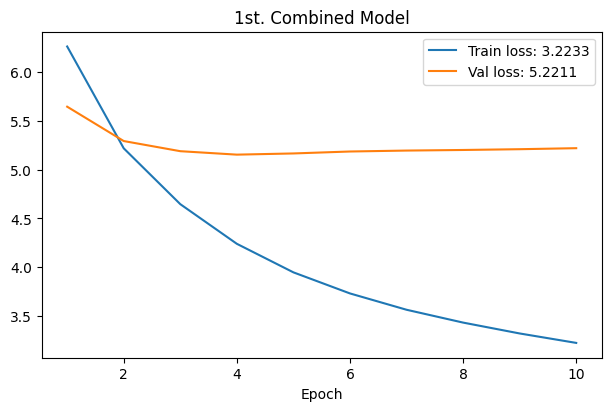

In [103]:
trainer.fit(model, train_data, val_data, 10, '../checkpoints/checkpoint_combined1.pt')

## 2nd. Model Instance

In [8]:
num_hiddens, num_blks, dropout = 512, 4, 0.3
ffn_num_hiddens, num_heads = 1024, 8

encoder = Model.TransformerEncoder(24000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 51)
decoder = Model.TransformerDecoder(48000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 51)
model = Model.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.0001, pad_id=0, device='cuda')
trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("2nd. Combined Model")

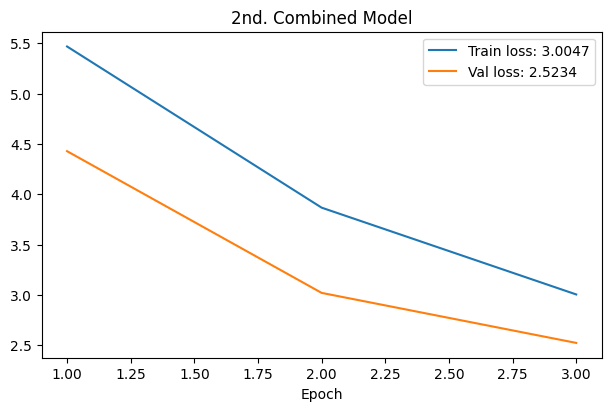

In [9]:
trainer.fit(model, train_data, val_data, 3, '../checkpoints/check_combined')

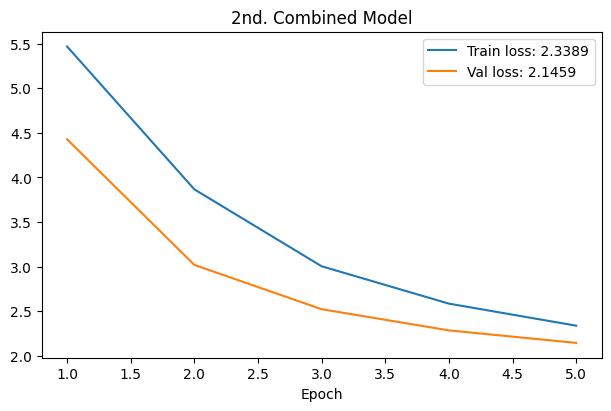

In [10]:
trainer.fit(model, train_data, val_data, 2, '../checkpoints/check_combined', False)

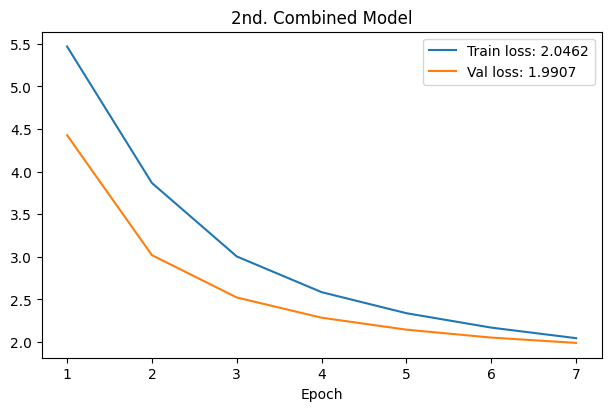

In [11]:
trainer.fit(model, train_data, val_data, 2, '../checkpoints/check_combined', False)

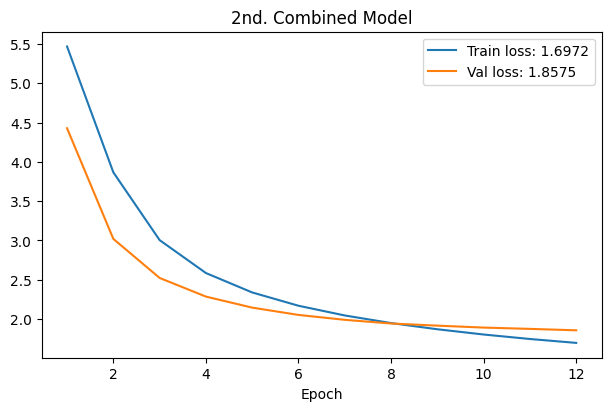

In [35]:
trainer.fit(model, train_data, val_data, 5, '../checkpoints/check_combined', False)

#### Loading Model Checkpoint

In [7]:
num_hiddens, num_blks, dropout = 512, 4, 0.3
ffn_num_hiddens, num_heads = 1024, 8
encoder = Model.TransformerEncoder(24000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 51)
decoder = Model.TransformerDecoder(48000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 51)
model = Model.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.0001, pad_id=0, device='cuda')
trainer = Trainer.TrainerModule(batch_size=64)
trainer.load_checkpoint(model, '../checkpoints/check_combined12.pt')

In [5]:
with open("../data/tokenizer_pol_combined.pkl", 'rb') as f:
    tokenizer_pol = pickle.load(f)

with open("../data/tokenizer_eng_combined.pkl", 'rb') as f:
    tokenizer_eng = pickle.load(f)

In [8]:
encoder_eng = BPEEncoder(tokenizer_eng.vocab, tokenizer_eng.vocab_chrs)
encoder_pol =  BPEEncoder(tokenizer_pol.vocab, tokenizer_pol.vocab_chrs, 65, True)
predicter = Predict.PredictionModule(model, encoder_eng, encoder_pol, tokenizer_pol)

In [11]:
print(predicter.predict_snt("Our country believes, that illegal immigrants do not previde any benefits for our community."))

['nasz_', 'kraj_', 'uważa_', ',_', 'że_', 'nielegalni_', 'imigranci_', 'nie_', 'przynoszą_', 'żadnych_', 'korzyści_', 'dla_', 'naszej_', 'społeczności_', '._']


In [20]:
print(predicter.predict_snt("He is not guilty, isn't he?"))

['nie_', 'jest_', 'winny_', ',_', 'prawda_', '?_']


In [24]:
print(predicter.predict_snt("Yesterday i went to the store, bought some bread, and came back home before it started to rain."))

['wczoraj_', 'poszedłem_', 'do_', 'sklepu_', ',_', 'kupiłem_', 'chleb_', 'i_', 'wróciłem_', 'do_', 'domu_', 'zanim_', 'zaczęło_', 'padać_', '._']
